In [ ]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from neural_net import NeuralNet
import examples.mushrooms as shroom
import graphics

In [3]:
from sklearn.model_selection import train_test_split

X, y = shroom.generate_mushrooms(lambda i, j: (i-0.5)**2 + (j-0.5)**2 < 0.16, size_shrooms=2048*16)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
epochs = 20
neural_net = NeuralNet((2, 32, 16, 1), learning_rate=0.001, random_state=42, dtype=np.float64)
losses, y_pred = neural_net.train(X_train, y_train, epochs=epochs, validate=(X_test, y_test), batch_size=16, binary=True)

EPOCH: 1    LOSS: 0.695135    LOSS CHANGE: 0    TEST ACCURACY: 0.503    TEST ACCURACY CHANGE: 0.503
EPOCH: 2    LOSS: 0.694015    LOSS CHANGE: -0.00112    TEST ACCURACY: 0.503    TEST ACCURACY CHANGE: 0
EPOCH: 3    LOSS: 0.693639    LOSS CHANGE: -0.0003757    TEST ACCURACY: 0.503    TEST ACCURACY CHANGE: 0
EPOCH: 4    LOSS: 0.693836    LOSS CHANGE: 0.0001966    TEST ACCURACY: 0.497    TEST ACCURACY CHANGE: -0.0058
EPOCH: 5    LOSS: 0.693098    LOSS CHANGE: -0.0007377    TEST ACCURACY: 0.503    TEST ACCURACY CHANGE: 0.0058
EPOCH: 6    LOSS: 0.690967    LOSS CHANGE: -0.002131    TEST ACCURACY: 0.518    TEST ACCURACY CHANGE: 0.0154
EPOCH: 7    LOSS: 0.684312    LOSS CHANGE: -0.006655    TEST ACCURACY: 0.489    TEST ACCURACY CHANGE: -0.0296
EPOCH: 8    LOSS: 0.664735    LOSS CHANGE: -0.01958    TEST ACCURACY: 0.655    TEST ACCURACY CHANGE: 0.166
EPOCH: 9    LOSS: 0.601581    LOSS CHANGE: -0.06315    TEST ACCURACY: 0.828    TEST ACCURACY CHANGE: 0.173
EPOCH: 10    LOSS: 0.467717    LOSS CHA

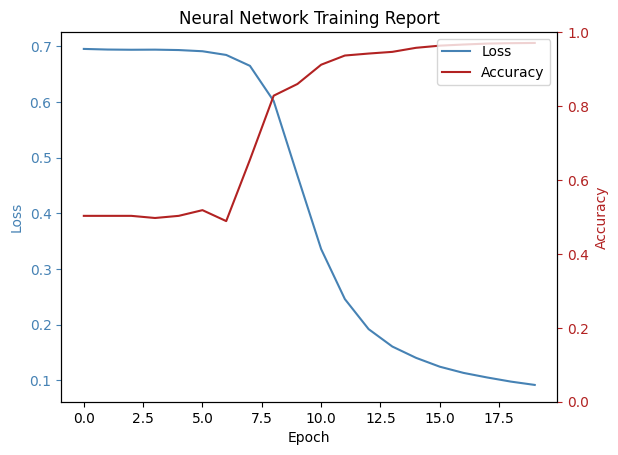

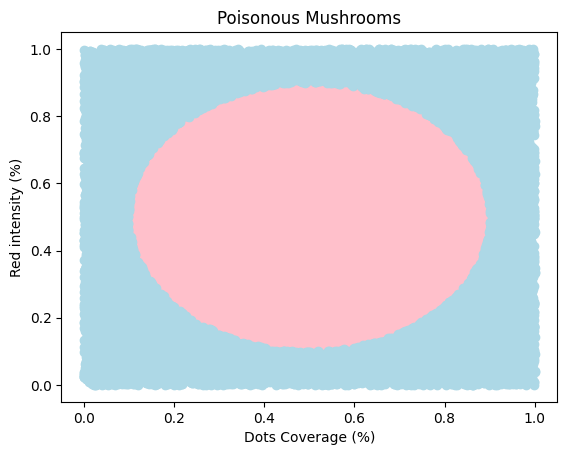

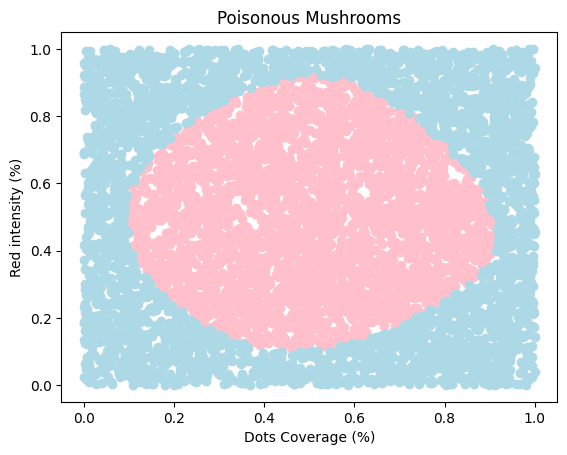

In [6]:
graphics.plot_report(neural_net)
shroom.plot_mushrooms(X, y)
y_pred_test = neural_net.predict(X_test)
shroom.plot_mushrooms(X_test, y_pred_test)

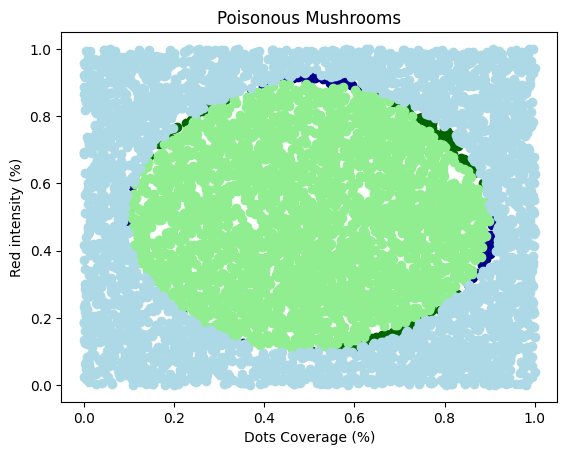

In [7]:
shroom.plot_mushroom_comparison(X_test, y_test, X_test, y_pred_test)